# Fase 3: Análisis de Rutas y Tiempos de Viaje

Este notebook analiza el tiempo de viaje promedio en las 10 rutas más transitadas por hora del día, utilizando los nombres reales de las zonas de origen y destino.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Librerías cargadas.")

Librerías cargadas.


In [2]:
print("Cargando datos limpios...")
df = pd.read_parquet('../datos/procesados/yellow_tripdata_2025-01_clean.parquet')
print(f"Dataset cargado con {len(df):,} viajes.")

print("Cargando lookup de zonas...")
lookup = pd.read_csv('../datos/raw/taxi_zone_lookup.csv')
print(f"Lookup cargado con {len(lookup)} zonas.")

Cargando datos limpios...
Dataset cargado con 3,250,191 viajes.
Cargando lookup de zonas...
Lookup cargado con 265 zonas.


In [3]:
print("Mapeando nombres reales de zonas...")
# Crear diccionarios para mapeo rápido
zone_dict = dict(zip(lookup['LocationID'], lookup['Zone']))

df['PU_Zone'] = df['PULocationID'].map(zone_dict).fillna('Unknown')
df['DO_Zone'] = df['DOLocationID'].map(zone_dict).fillna('Unknown')

# Excluir rutas con zonas 'Unknown'
df = df[(df['PU_Zone'] != 'Unknown') & (df['DO_Zone'] != 'Unknown')]
df = df[(df['PU_Zone'] != 'NV') & (df['DO_Zone'] != 'NV')]

# Crear la columna Ruta
df['Ruta'] = df['PU_Zone'] + " -> " + df['DO_Zone']
print("Mapeo completado y columna Ruta creada.")

Mapeando nombres reales de zonas...
Mapeo completado y columna Ruta creada.


In [4]:
print("Identificando el Top 10 de rutas más frecuentes...")
# Filtramos viajes donde origen = destino si queremos ver traslados reales, 
# pero NYC tiene mucha demanda intra-zona. Por ahora mantenemos todas, pero
# vamos a ver cuáles son:
top_routes = df['Ruta'].value_counts().head(10)
print("\nTop 10 Rutas:")
print(top_routes)

top_10_nombres = top_routes.index.tolist()
df_top = df[df['Ruta'].isin(top_10_nombres)]
print(f"\nFilas retenidas para el análisis del Top 10: {len(df_top):,} viajes")

Identificando el Top 10 de rutas más frecuentes...

Top 10 Rutas:
Ruta
Upper East Side South -> Upper East Side North    24368
Upper East Side North -> Upper East Side South    21324
Upper East Side North -> Upper East Side North    17106
Upper East Side South -> Upper East Side South    16232
Midtown Center -> Upper East Side South           11152
Upper East Side South -> Midtown Center            9893
Midtown Center -> Upper East Side North            9575
Upper West Side South -> Upper West Side North     9324
Lincoln Square East -> Upper West Side South       8935
Upper West Side South -> Lincoln Square East       8568
Name: count, dtype: int64

Filas retenidas para el análisis del Top 10: 136,477 viajes


In [8]:
print("Calculando tiempo promedio de viaje por hora...")
# Agrupar por Ruta y hora del día
tiempo_rutas_hora = df_top.groupby(['Ruta', 'hora_dia'])['duracion_minutos'].mean().reset_index()
display(tiempo_rutas_hora.head(24))

Calculando tiempo promedio de viaje por hora...


,Ruta,hora_dia,duracion_minutos
0,Lincoln Square East -> Upper West Side South,0,5.810556
1,Lincoln Square East -> Upper West Side South,1,5.096099
2,Lincoln Square East -> Upper West Side South,2,5.509804
3,Lincoln Square East -> Upper West Side South,3,5.485417
4,Lincoln Square East -> Upper West Side South,4,3.492857
5,Lincoln Square East -> Upper West Side South,5,4.137500
6,Lincoln Square East -> Upper West Side South,6,3.740476
7,Lincoln Square East -> Upper West Side South,7,4.915566
8,Lincoln Square East -> Upper West Side South,8,5.284418
9,Lincoln Square East -> Upper West Side South,9,5.725430


Generando visualización...
Gráfica guardada exitosamente en: ../resultados/graficos/rutas_tiempos_viaje.png


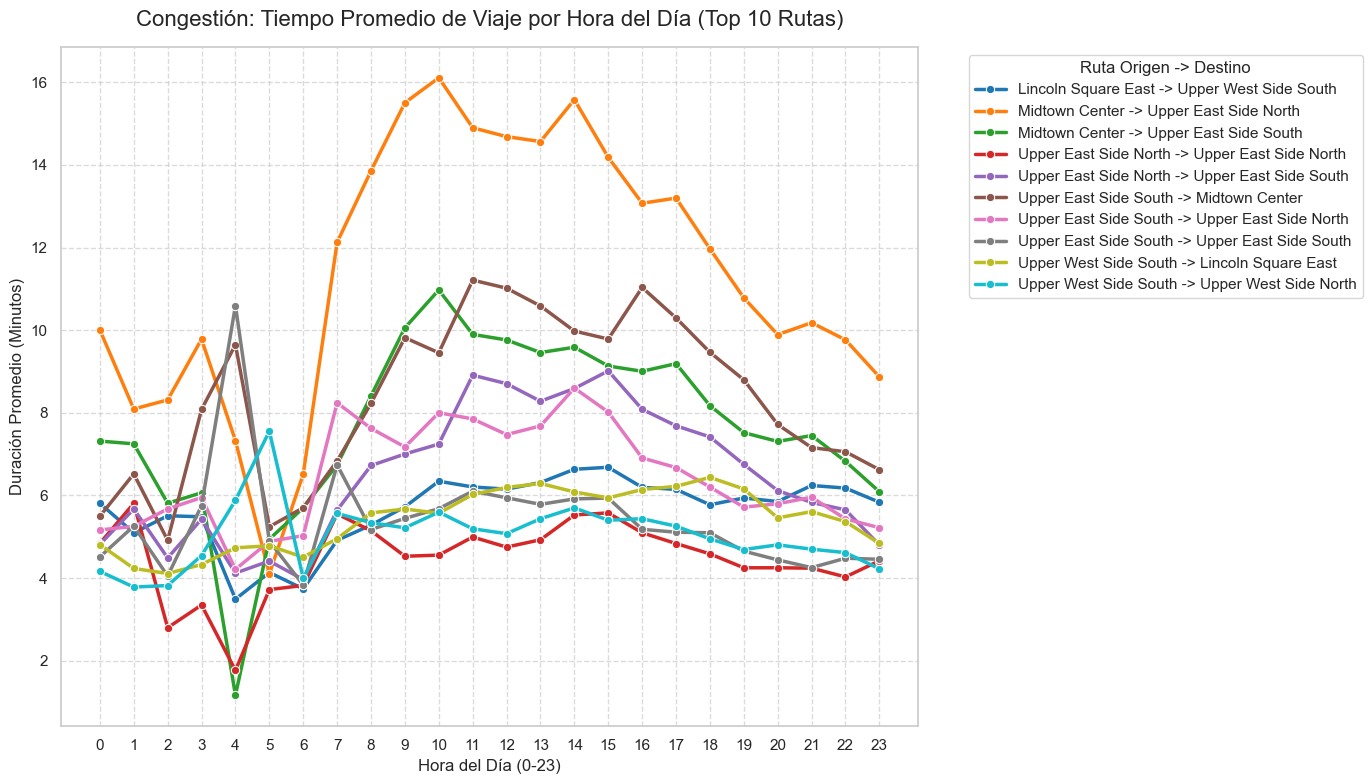

In [6]:
print("Generando visualización...")
import os
os.makedirs('../resultados/graficos', exist_ok=True)

plt.figure(figsize=(14, 8))
# Usamos un palette categórico que distinga bien las 10 líneas
sns.lineplot(
    data=tiempo_rutas_hora, 
    x='hora_dia', 
    y='duracion_minutos', 
    hue='Ruta', 
    marker='o',
    linewidth=2.5,
    palette='tab10'
)

plt.title('Congestión: Tiempo Promedio de Viaje por Hora del Día (Top 10 Rutas)', fontsize=16, pad=15)
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Duración Promedio (Minutos)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Ruta Origen -> Destino', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Guardar la gráfica
grafico_path = '../resultados/graficos/rutas_tiempos_viaje.png'
plt.savefig(grafico_path, dpi=300, bbox_inches='tight')
print(f"Gráfica guardada exitosamente en: {grafico_path}")
plt.show()